# 02 — Fase 1: respostas baseline (AQuA + GSM8K)

Modelos respondem às questões com raciocínio explícito (CoT), temperatura 0. As respostas do TREINO alimentarão a geração de reflexões (Fase 2); as do TESTE são o baseline "sem reflexão" (decisão D3a do notebook 01).

**Decisões deste notebook:**

| # | Decisão | Escolha | Racional |
|---|---|---|---|
| D7 | Escopo | AQuA + GSM8K, 1.000 treino / 250 teste cada | Mesma quantidade → comparabilidade direta; são os dois datasets de maior impacto esperado |
| D8 | Subamostragem AQuA | Estratificada por cluster (K-Means sobre TF-IDF→SVD), proporcional, seed 42 | Selecionar "os mais similares" inflaria a Transferability artificialmente; estratificar preserva a diversidade real. "Mais similares" pode virar ablação (upper bound de memória ideal) |
| D9 | Prompt | CoT livre + linha final obrigatória `FINAL ANSWER: X`; resposta bruta 100% armazenada | O trace completo custa só disco e preserva opcionalidade: o que o refletor vê (trace completo vs. só resposta) vira variável experimental na Fase 2. JSON estruturado degrada raciocínio de modelos pequenos; resposta direta sem CoT só permite reflexão genérica |
| D10 | Extração | Cascata de regex + taxa de inválidas como métrica | Respostas inválidas foram problema no paper original — aqui viram medida, não recorte |

**Métricas coletadas por questão:** latência total, tokens de prompt/geração, velocidade (tokens/s), comprimento do raciocínio, resposta extraída, validade, acerto. Tudo em JSONL **resumável** (reexecutar pula o que já foi respondido).

**Modelos:** `phi4-mini` e `llama3.1:8b` via Ollama local. Se o Ollama não estiver disponível, o notebook roda em **modo MOCK** (gera respostas sintéticas) só para validar o pipeline — os números de mock não significam nada.

In [1]:
import json, re, time, hashlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

SEED = 42
N_TRAIN, N_TEST = 1000, 250
MODELS = ["phi4-mini", "llama3.1:8b"]
OLLAMA_URL = "http://localhost:11434"
GEN_OPTIONS = {"temperature": 0.0, "seed": SEED, "num_predict": 1024, "num_ctx": 4096}

DATA   = Path("..") / "data" / "mcq"
SPLITS = Path("..") / "data" / "splits"
RES    = Path("..") / "results" / "fase1"
SPLITS.mkdir(parents=True, exist_ok=True)
RES.mkdir(parents=True, exist_ok=True)

## 1. Splits congelados

Regra: se os arquivos em `data/splits/` já existem, **carrega e nunca regenera** (splits são imutáveis após a primeira execução; deletar os arquivos força regeneração). AQuA passa por deduplicação exata antes da amostragem — o treino tem 97k questões com repetições conhecidas.

In [2]:
def norm_q(s):
    return re.sub(r"\s+", " ", str(s).strip().lower())

aqua_train_full = pd.read_parquet(DATA / "aqua/train.parquet")
aqua_test_full  = pd.read_parquet(DATA / "aqua/test.parquet")
gsm_train_full  = pd.read_parquet(DATA / "gsm8k/train.parquet")
gsm_test_full   = pd.read_parquet(DATA / "gsm8k/test.parquet")

# dedup exata no treino do AQuA (e contra o teste, para evitar contaminação)
aqua_train_full["_k"] = aqua_train_full["question"].map(norm_q)
test_keys = set(aqua_test_full["question"].map(norm_q))
before = len(aqua_train_full)
aqua_train_full = (aqua_train_full.drop_duplicates("_k")
                   .loc[lambda d: ~d["_k"].isin(test_keys)]
                   .drop(columns="_k"))
print(f"AQuA treino: {before:,} -> {len(aqua_train_full):,} após dedup/anticontaminação")

AQuA treino: 97,467 -> 80,618 após dedup/anticontaminação


In [3]:
SPLIT_FILES = {
    ("aqua", "train"):  SPLITS / "aqua_train.parquet",
    ("aqua", "test"):   SPLITS / "aqua_test.parquet",
    ("gsm8k", "train"): SPLITS / "gsm8k_train.parquet",
    ("gsm8k", "test"):  SPLITS / "gsm8k_test.parquet",
}

if all(p.exists() for p in SPLIT_FILES.values()):
    splits = {k: pd.read_parquet(p) for k, p in SPLIT_FILES.items()}
    print("Splits existentes carregados (imutáveis).")
else:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import TruncatedSVD
    from sklearn.cluster import MiniBatchKMeans

    # --- AQuA treino: estratificado por cluster (D8) ---
    tfidf = TfidfVectorizer(max_features=20000, sublinear_tf=True, stop_words="english")
    X = tfidf.fit_transform(aqua_train_full["question"])
    Xr = TruncatedSVD(n_components=50, random_state=SEED).fit_transform(X)
    km = MiniBatchKMeans(n_clusters=25, random_state=SEED, n_init=3).fit(Xr)
    aqua_train_full["cluster"] = km.labels_

    quota = (aqua_train_full["cluster"].value_counts(normalize=True) * N_TRAIN).round().astype(int)
    parts = [g.sample(min(quota[c], len(g)), random_state=SEED)
             for c, g in aqua_train_full.groupby("cluster")]
    aqua_tr = pd.concat(parts)
    # ajusta para exatamente N_TRAIN
    if len(aqua_tr) > N_TRAIN:
        aqua_tr = aqua_tr.sample(N_TRAIN, random_state=SEED)
    elif len(aqua_tr) < N_TRAIN:
        extra = aqua_train_full.drop(aqua_tr.index).sample(N_TRAIN - len(aqua_tr), random_state=SEED)
        aqua_tr = pd.concat([aqua_tr, extra])

    splits = {
        ("aqua", "train"):  aqua_tr.reset_index(drop=True),
        ("aqua", "test"):   aqua_test_full.sample(N_TEST, random_state=SEED).reset_index(drop=True),
        ("gsm8k", "train"): gsm_train_full.sample(N_TRAIN, random_state=SEED).reset_index(drop=True),
        ("gsm8k", "test"):  gsm_test_full.sample(N_TEST, random_state=SEED).reset_index(drop=True),
    }
    for k, df in splits.items():
        df.to_parquet(SPLIT_FILES[k])

    manifest = {f"{ds}_{sp}": {"n": len(df), "seed": SEED,
                "sha": hashlib.sha256("".join(sorted(df["id"].astype(str))).encode()).hexdigest()[:12]}
                for (ds, sp), df in splits.items()}
    manifest["method"] = {"aqua_train": "dedup + anticontaminação + MiniBatchKMeans(25) estratificado",
                          "outros": "amostra aleatória simples"}
    (SPLITS / "manifest.json").write_text(json.dumps(manifest, indent=2))
    print("Splits gerados e congelados.")

for (ds, sp), df in splits.items():
    print(f"{ds:6s} {sp:5s} {len(df):5d} questões")

Splits existentes carregados (imutáveis).
aqua   train  1000 questões
aqua   test    250 questões
gsm8k  train  1000 questões
gsm8k  test    250 questões


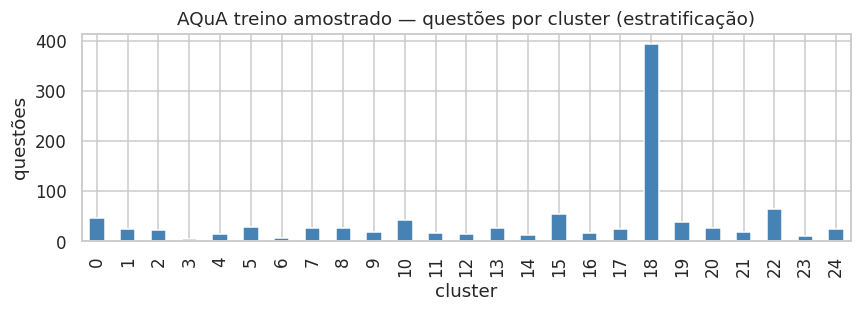

In [4]:
# Sanidade: distribuição de clusters do AQuA amostrado (se acabou de gerar)
if "cluster" in splits[("aqua", "train")].columns:
    fig, ax = plt.subplots(figsize=(8, 3))
    splits[("aqua", "train")]["cluster"].value_counts().sort_index().plot.bar(ax=ax, color="steelblue")
    ax.set(title="AQuA treino amostrado — questões por cluster (estratificação)",
           xlabel="cluster", ylabel="questões")
    plt.tight_layout(); plt.show()

## 2. Prompt (D9)

Requisitos: (a) forçar o raciocínio explícito ANTES da resposta — o trace é insumo da reflexão na Fase 2; (b) formato de saída extraível de forma robusta; (c) simples o bastante para modelos pequenos não se perderem no formato. Prompt em inglês (idioma dos datasets).

In [5]:
PROMPT_TEMPLATE = '''You are solving a multiple-choice question. Think through the problem step by step, showing all your reasoning. Then give your final answer.

Question:
{question}

Options:
{options}

Rules:
- Reason step by step BEFORE answering.
- You must choose exactly one option.
- The LAST line of your response must be exactly: FINAL ANSWER: <letter>'''

def format_prompt(row):
    ch = row["choices"]
    opts = "\n".join(f"{l}) {t}" for l, t in zip(ch["label"], ch["text"]))
    return PROMPT_TEMPLATE.format(question=row["question"], options=opts)

PROMPT_SHA = hashlib.sha256(PROMPT_TEMPLATE.encode()).hexdigest()[:12]
print(format_prompt(splits[("aqua", "train")].iloc[0]))
print("\nprompt_sha:", PROMPT_SHA)

You are solving a multiple-choice question. Think through the problem step by step, showing all your reasoning. Then give your final answer.

Question:
Arjun started a business with Rs. 40,000 and is joined afterwards by Anoop with Rs.80, 000. After how many months did Anoop join if the profits at the end of the year are divided equally?

Options:
A) 3
B) 4
C) 5
D) 6
E) 7

Rules:
- Reason step by step BEFORE answering.
- You must choose exactly one option.
- The LAST line of your response must be exactly: FINAL ANSWER: <letter>

prompt_sha: b870d2fde6f0


## 3. Extração da resposta (D10)

Cascata em ordem de confiança: (1) `FINAL ANSWER: X`; (2) "the answer is (X)"; (3) "option X"; (4) **casamento por valor** — o modelo deu o valor da alternativa em vez da letra ("the answer is 18"), casado contra os textos das opções após normalização, e só se o match for único; (5) letra **inequívoca** no fim do texto ("(C)", "C)", letra sozinha) — formas que evitam capturar o artigo inglês "A".

**Se tudo falhar o retorno é `(None, None)`** — nunca o texto completo: `pred=None`, a questão conta como inválida (métrica D10) e a resposta bruta permanece íntegra no `raw_response` para auditoria e para a reflexão da Fase 2. O campo `extraction_method` registra qual regra casou, permitindo medir a fração extraída por regras de menor confiança.

In [6]:
def _norm_val(s):
    # normaliza valores para comparação: "$1,500.00" -> "1500"
    s = re.sub(r"[\s,$]", "", str(s).strip().lower()).rstrip(".")
    try:
        return f"{float(s):g}"
    except ValueError:
        return s

def extract_answer(text, labels, texts=None):
    """Retorna (letra, método) ou (None, None).
    NUNCA retorna o texto completo: se nada casar, pred=None e a questão
    conta como INVÁLIDA na métrica — a resposta bruta fica no raw_response.
    Métodos, em ordem de confiança: final_answer > answer_is > option
    > value_match (modelo deu o VALOR da alternativa, não a letra)
    > tail_letter (letra inequívoca no fim do texto)."""
    labels = [str(l).upper() for l in labels]
    lab = "".join(labels)
    t = str(text)

    for method, pat in [
        ("final_answer", rf"FINAL\s*ANSWER\s*[:\-]?\s*\(?([{lab}])\b\)?"),
        ("answer_is",    rf"(?:the\s+)?answer\s+is\s*[:\-]?\s*\(?([{lab}])\b\)?"),
        ("option",       rf"(?:correct\s+option|option)\s*[:\-]?\s*\(?([{lab}])\b\)?"),
    ]:
        m = list(re.finditer(pat, t, flags=re.IGNORECASE))
        if m:
            return m[-1].group(1).upper(), method

    # casamento por VALOR: "FINAL ANSWER: 18" / "the answer is 18"
    if texts is not None:
        cand = None
        for pat in [r"FINAL\s*ANSWER\s*[:\-]?\s*(.+)",
                    r"(?:the\s+)?answer\s+is\s*[:\-]?\s*([^\n.]+)"]:
            m = list(re.finditer(pat, t, flags=re.IGNORECASE))
            if m:
                cand = m[-1].group(1)
                break
        if cand:
            cn = _norm_val(cand)
            hits = [l for l, tx in zip(labels, texts) if cn != "" and _norm_val(tx) == cn]
            if len(hits) == 1:
                return hits[0], "value_match"

    # último recurso: letra no FIM do texto em forma inequívoca — "(C)", "C)",
    # "C." ou letra sozinha encerrando o texto. Evita capturar o artigo "A ...".
    tail = t[-200:]
    m = list(re.finditer(rf"\(([{lab}])\)|(?:^|\s)([{lab}])[).:]?\s*$", tail, flags=re.MULTILINE))
    if m:
        g = m[-1]
        return (g.group(1) or g.group(2)).upper(), "tail_letter"

    return None, None

_L = list("ABCDE")
_T = ["12", "15", "18", "21", "25"]
assert extract_answer("bla bla\nFINAL ANSWER: C", _L) == ("C", "final_answer")
assert extract_answer("final answer: (b)", _L)[0] == "B"
assert extract_answer("So the answer is A.", _L)[0] == "A"
assert extract_answer("... I conclude it must be D", _L)[0] == "D"
assert extract_answer("A) is wrong... FINAL ANSWER: E", _L)[0] == "E"
# valor em vez de letra:
assert extract_answer("FINAL ANSWER: 18", _L, _T) == ("C", "value_match")
assert extract_answer("the answer is $1,500", _L, ["1500", "2", "3", "4", "5"])[0] == "A"
assert extract_answer("answer is 18 or 21, not sure", _L, _T)[0] is None  # ambíguo -> inválida
# artigo "A" não é resposta:
assert extract_answer("A common mistake would be to guess here.", _L)[0] is None
assert extract_answer("Between the options, hard to say.", _L)[0] is None  # "B" de Between não casa
assert extract_answer("no letters here 123", _L)[0] is None
print("extrator OK")

extrator OK


## 4. Cliente Ollama (+ modo MOCK)

Coletamos as métricas nativas do Ollama: `total_duration`, `load_duration`, `prompt_eval_count/duration` (tokens e tempo do prompt) e `eval_count/duration` (tokens e tempo da geração). Se o Ollama não responder, ativa-se o MOCK — respostas sintéticas determinísticas só para validar o pipeline de ponta a ponta.

In [7]:
def ollama_available():
    try:
        return requests.get(f"{OLLAMA_URL}/api/tags", timeout=3).status_code == 200
    except Exception:
        return False

MOCK = not ollama_available()
# Saídas mock vão para pasta separada: NUNCA misturar com resultados reais,
# senão o runner resumável pularia questões achando que já foram respondidas.
RES_OUT = RES.parent / "fase1_mock" if MOCK else RES
RES_OUT.mkdir(parents=True, exist_ok=True)
print(f"{'MOCK MODE (Ollama indisponível — números sem significado)' if MOCK else 'Ollama disponível — execução real'} -> {RES_OUT.name}/")

def call_ollama(model, prompt):
    t0 = time.perf_counter()
    r = requests.post(f"{OLLAMA_URL}/api/chat", json={
        "model": model,
        "messages": [{"role": "user", "content": prompt}],
        "stream": False,
        "options": GEN_OPTIONS,
    }, timeout=600)
    r.raise_for_status()
    d = r.json()
    return {
        "raw_response": d["message"]["content"],
        "wall_time_s": time.perf_counter() - t0,
        "total_duration_s": d.get("total_duration", 0) / 1e9,
        "load_duration_s": d.get("load_duration", 0) / 1e9,
        "prompt_tokens": d.get("prompt_eval_count"),
        "gen_tokens": d.get("eval_count"),
        "gen_duration_s": d.get("eval_duration", 0) / 1e9,
    }

def call_mock(model, prompt, qid, labels):
    h = int(hashlib.sha256(f"{model}|{qid}".encode()).hexdigest(), 16)
    letter = labels[h % len(labels)]
    body = f"Step 1: mock reasoning about the problem. Step 2: more mock steps ({h % 97} tokens of thought)."
    text = body + (f"\nFINAL ANSWER: {letter}" if h % 10 else "\n(no final line - simulated failure)")
    return {"raw_response": text, "wall_time_s": 0.01 + (h % 100) / 1000,
            "total_duration_s": 0.01, "load_duration_s": 0.0,
            "prompt_tokens": len(prompt.split()), "gen_tokens": len(text.split()),
            "gen_duration_s": 0.01}

MOCK MODE (Ollama indisponível — números sem significado) -> fase1_mock/


## 5. Runner resumável

Um JSONL por (modelo, dataset, split) em `results/fase1/`. Cada linha = questão respondida, com a resposta bruta completa. Reexecutar a célula **pula** o que já existe — seguro para rodadas longas interrompidas.

In [8]:
def slug(s):
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")

def out_path(model, ds, sp):
    return RES_OUT / f"{slug(model)}__{ds}__{sp}.jsonl"

def load_done(path):
    if not path.exists():
        return set()
    with open(path, encoding="utf-8") as f:
        return {json.loads(l)["id"] for l in f if l.strip()}

def run(model, ds, sp, limit=None):
    df = splits[(ds, sp)]
    if limit:
        df = df.head(limit)
    path = out_path(model, ds, sp)
    done = load_done(path)
    todo = df[~df["id"].astype(str).isin(done)]
    print(f"{model} × {ds}/{sp}: {len(done)} feitas, {len(todo)} restantes -> {path.name}")
    t_start = time.perf_counter()
    with open(path, "a", encoding="utf-8") as f:
        for i, (_, row) in enumerate(todo.iterrows(), 1):
            labels = [str(l).upper() for l in row["choices"]["label"]]
            prompt = format_prompt(row)
            try:
                out = (call_mock(model, prompt, row["id"], labels) if MOCK
                       else call_ollama(model, prompt))
            except Exception as e:
                out = {"raw_response": f"__ERROR__ {e}", "wall_time_s": None,
                       "total_duration_s": None, "load_duration_s": None,
                       "prompt_tokens": None, "gen_tokens": None, "gen_duration_s": None}
            texts = [str(x) for x in row["choices"]["text"]]
            pred, method = extract_answer(out["raw_response"], labels, texts)
            rec = {"id": str(row["id"]), "dataset": ds, "split": sp, "model": model,
                   "mock": MOCK, "prompt_sha": PROMPT_SHA, "seed": SEED,
                   "gold": str(row["answerKey"]).upper(), "pred": pred,
                   "valid": pred is not None, "extraction_method": method,
                   "strict_format": method == "final_answer",
                   "correct": pred == str(row["answerKey"]).upper(),
                   "ts": time.strftime("%Y-%m-%dT%H:%M:%S"), **out}
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
            if i % 50 == 0 or i == len(todo):
                el = time.perf_counter() - t_start
                print(f"  {i}/{len(todo)}  ({el/60:.1f} min, {el/i:.1f} s/questão)")
    return path

In [9]:
# Plano de execução — comente linhas para rodar por partes.
# Estimativa real (GPU local, modelos 4–8B): ~5–20 s/questão
# -> 1.250 questões × 2 modelos × 2 datasets ≈ 7–28 h no total. O runner é
# resumável: pode interromper e retomar à vontade, ou rodar um modelo por noite.
RUN_PLAN = [(m, ds, sp) for m in MODELS for ds in ("aqua", "gsm8k") for sp in ("train", "test")]

for m, ds, sp in RUN_PLAN:
    run(m, ds, sp)

phi4-mini × aqua/train: 0 feitas, 1000 restantes -> phi4_mini__aqua__train.jsonl
  50/1000  (0.0 min, 0.0 s/questão)
  100/1000  (0.0 min, 0.0 s/questão)
  150/1000  (0.0 min, 0.0 s/questão)
  200/1000  (0.0 min, 0.0 s/questão)
  250/1000  (0.0 min, 0.0 s/questão)
  300/1000  (0.0 min, 0.0 s/questão)
  350/1000  (0.0 min, 0.0 s/questão)
  400/1000  (0.0 min, 0.0 s/questão)
  450/1000  (0.0 min, 0.0 s/questão)
  500/1000  (0.0 min, 0.0 s/questão)
  550/1000  (0.0 min, 0.0 s/questão)
  600/1000  (0.0 min, 0.0 s/questão)
  650/1000  (0.0 min, 0.0 s/questão)
  700/1000  (0.0 min, 0.0 s/questão)
  750/1000  (0.0 min, 0.0 s/questão)
  800/1000  (0.0 min, 0.0 s/questão)
  850/1000  (0.0 min, 0.0 s/questão)
  900/1000  (0.0 min, 0.0 s/questão)
  950/1000  (0.0 min, 0.0 s/questão)
  1000/1000  (0.0 min, 0.0 s/questão)
phi4-mini × aqua/test: 0 feitas, 250 restantes -> phi4_mini__aqua__test.jsonl
  50/250  (0.0 min, 0.0 s/questão)
  100/250  (0.0 min, 0.0 s/questão)
  150/250  (0.0 min, 0.0 s/que

phi4-mini × gsm8k/train: 0 feitas, 1000 restantes -> phi4_mini__gsm8k__train.jsonl
  50/1000  (0.0 min, 0.0 s/questão)
  100/1000  (0.0 min, 0.0 s/questão)


  150/1000  (0.0 min, 0.0 s/questão)
  200/1000  (0.0 min, 0.0 s/questão)
  250/1000  (0.0 min, 0.0 s/questão)
  300/1000  (0.0 min, 0.0 s/questão)
  350/1000  (0.0 min, 0.0 s/questão)
  400/1000  (0.0 min, 0.0 s/questão)
  450/1000  (0.0 min, 0.0 s/questão)


  500/1000  (0.0 min, 0.0 s/questão)
  550/1000  (0.0 min, 0.0 s/questão)
  600/1000  (0.0 min, 0.0 s/questão)
  650/1000  (0.0 min, 0.0 s/questão)
  700/1000  (0.0 min, 0.0 s/questão)
  750/1000  (0.0 min, 0.0 s/questão)
  800/1000  (0.0 min, 0.0 s/questão)
  850/1000  (0.0 min, 0.0 s/questão)
  900/1000  (0.0 min, 0.0 s/questão)
  950/1000  (0.0 min, 0.0 s/questão)
  1000/1000  (0.0 min, 0.0 s/questão)
phi4-mini × gsm8k/test: 0 feitas, 250 restantes -> phi4_mini__gsm8k__test.jsonl
  50/250  (0.0 min, 0.0 s/questão)
  100/250  (0.0 min, 0.0 s/questão)
  150/250  (0.0 min, 0.0 s/questão)
  200/250  (0.0 min, 0.0 s/questão)
  250/250  (0.0 min, 0.0 s/questão)
llama3.1:8b × aqua/train: 0 feitas, 1000 restantes -> llama3_1_8b__aqua__train.jsonl
  50/1000  (0.0 min, 0.0 s/questão)
  100/1000  (0.0 min, 0.0 s/questão)
  150/1000  (0.0 min, 0.0 s/questão)
  200/1000  (0.0 min, 0.0 s/questão)
  250/1000  (0.0 min, 0.0 s/questão)
  300/1000  (0.0 min, 0.0 s/questão)
  350/1000  (0.0 min, 0.0 s

  500/1000  (0.0 min, 0.0 s/questão)
  550/1000  (0.0 min, 0.0 s/questão)
  600/1000  (0.0 min, 0.0 s/questão)
  650/1000  (0.0 min, 0.0 s/questão)
  700/1000  (0.0 min, 0.0 s/questão)
  750/1000  (0.0 min, 0.0 s/questão)


  800/1000  (0.0 min, 0.0 s/questão)
  850/1000  (0.0 min, 0.0 s/questão)
  900/1000  (0.0 min, 0.0 s/questão)


  950/1000  (0.0 min, 0.0 s/questão)
  1000/1000  (0.0 min, 0.0 s/questão)
llama3.1:8b × aqua/test: 0 feitas, 250 restantes -> llama3_1_8b__aqua__test.jsonl
  50/250  (0.0 min, 0.0 s/questão)
  100/250  (0.0 min, 0.0 s/questão)
  150/250  (0.0 min, 0.0 s/questão)
  200/250  (0.0 min, 0.0 s/questão)
  250/250  (0.0 min, 0.0 s/questão)
llama3.1:8b × gsm8k/train: 0 feitas, 1000 restantes -> llama3_1_8b__gsm8k__train.jsonl
  50/1000  (0.0 min, 0.0 s/questão)
  100/1000  (0.0 min, 0.0 s/questão)
  150/1000  (0.0 min, 0.0 s/questão)
  200/1000  (0.0 min, 0.0 s/questão)
  250/1000  (0.0 min, 0.0 s/questão)
  300/1000  (0.0 min, 0.0 s/questão)
  350/1000  (0.0 min, 0.0 s/questão)
  400/1000  (0.0 min, 0.0 s/questão)
  450/1000  (0.0 min, 0.0 s/questão)
  500/1000  (0.0 min, 0.0 s/questão)
  550/1000  (0.0 min, 0.0 s/questão)
  600/1000  (0.0 min, 0.0 s/questão)
  650/1000  (0.0 min, 0.0 s/questão)
  700/1000  (0.0 min, 0.0 s/questão)
  750/1000  (0.0 min, 0.0 s/questão)
  800/1000  (0.0 min, 0

  950/1000  (0.0 min, 0.0 s/questão)
  1000/1000  (0.0 min, 0.0 s/questão)


llama3.1:8b × gsm8k/test: 0 feitas, 250 restantes -> llama3_1_8b__gsm8k__test.jsonl
  50/250  (0.0 min, 0.0 s/questão)
  100/250  (0.0 min, 0.0 s/questão)
  150/250  (0.0 min, 0.0 s/questão)
  200/250  (0.0 min, 0.0 s/questão)
  250/250  (0.0 min, 0.0 s/questão)


## 6. Métricas

Carrega todos os JSONL e agrega: acurácia, taxa de inválidas, aderência ao formato estrito, latência (média/p50/p95), tokens gerados, velocidade e comprimento do raciocínio.

In [10]:
rows = []
for p in sorted(RES_OUT.glob("*.jsonl")):
    with open(p, encoding="utf-8") as f:
        rows += [json.loads(l) for l in f if l.strip()]
res_df = pd.DataFrame(rows)
if res_df.empty:
    raise SystemExit("Sem resultados ainda.")
if res_df["mock"].any():
    print("⚠️  Há resultados MOCK — números apenas para validar o pipeline!")

res_df["reason_words"] = res_df["raw_response"].str.split().str.len()
res_df["tok_per_s"] = res_df["gen_tokens"] / res_df["gen_duration_s"].replace(0, np.nan)

metrics = (res_df.groupby(["model", "dataset", "split"])
           .agg(n=("id", "count"),
                acuracia=("correct", "mean"),
                invalidas=("valid", lambda s: 1 - s.mean()),
                formato_estrito=("strict_format", "mean"),
                lat_media_s=("wall_time_s", "mean"),
                lat_p50_s=("wall_time_s", "median"),
                lat_p95_s=("wall_time_s", lambda s: s.quantile(0.95)),
                tokens_gerados=("gen_tokens", "mean"),
                tok_por_s=("tok_per_s", "mean"),
                palavras_raciocinio=("reason_words", "mean"))
           .round(3))
metrics

⚠️  Há resultados MOCK — números apenas para validar o pipeline!


n  acuracia  invalidas  formato_estrito  \
model       dataset split                                               
llama3.1:8b aqua    test    250     0.212      0.100            0.900   
                    train  1000     0.180      0.094            0.906   
            gsm8k   test    250     0.212      0.076            0.924   
                    train  1000     0.202      0.106            0.894   
phi4-mini   aqua    test    250     0.120      0.076            0.924   
                    train  1000     0.187      0.108            0.892   
            gsm8k   test    250     0.272      0.072            0.928   
                    train  1000     0.215      0.093            0.907   

                           lat_media_s  lat_p50_s  lat_p95_s  tokens_gerados  \
model       dataset split                                                      
llama3.1:8b aqua    test         0.058      0.056      0.104          19.300   
                    train        0.061      0.062      0.104          19.282   
            gsm8k   test         0.062      0.062      0.103          19.228   
                    train        0.057      0.055      0.104          19.318   
phi4-mini   aqua    test         0.059      0.060      0.103          19.228   
                    train        0.060      0.061      0.105          19.324   
            gsm8k   test         0.059      0.059      0.105          19.216   
                    train        0.059      0.060      0.103          19.279   

                           tok_por_s  palavras_raciocinio  
model       dataset split                                  
llama3.1:8b aqua    test      1930.0               19.300  
                    train     1928.2               19.282  
            gsm8k   test      1922.8               19.228  
                    train     1931.8               19.318  
phi4-mini   aqua    test      1922.8               19.228  
                    train     1932.4               19.324  
            gsm8k   test      1921.6               19.216  
                    train     1927.9               19.279

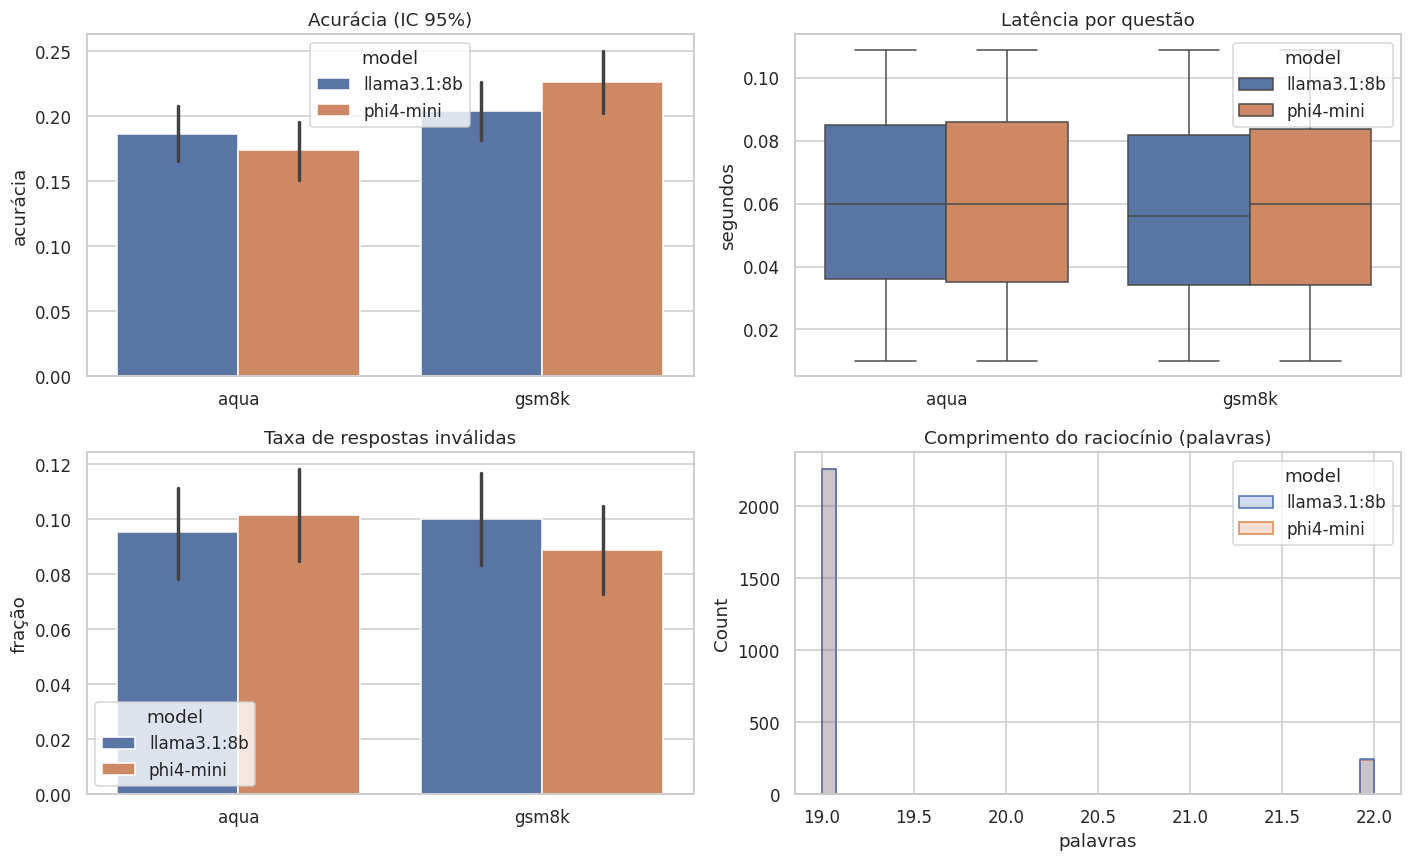

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.barplot(data=res_df, x="dataset", y="correct", hue="model", ax=axes[0, 0], errorbar=("ci", 95))
axes[0, 0].set(title="Acurácia (IC 95%)", ylabel="acurácia", xlabel="")

sns.boxplot(data=res_df, x="dataset", y="wall_time_s", hue="model", ax=axes[0, 1], showfliers=False)
axes[0, 1].set(title="Latência por questão", ylabel="segundos", xlabel="")

sns.barplot(data=res_df.assign(inv=~res_df["valid"]), x="dataset", y="inv", hue="model", ax=axes[1, 0])
axes[1, 0].set(title="Taxa de respostas inválidas", ylabel="fração", xlabel="")

sns.histplot(data=res_df, x="reason_words", hue="model", element="step", ax=axes[1, 1], bins=40)
axes[1, 1].set(title="Comprimento do raciocínio (palavras)", xlabel="palavras")

plt.tight_layout(); plt.show()

In [12]:
# Acurácia condicionada: acerta mais quando raciocina mais? (proxy de esforço)
res_df["len_bin"] = pd.qcut(res_df["reason_words"], 4, duplicates="drop")
cond = res_df.groupby(["model", "dataset", "len_bin"])["correct"].mean().unstack()
display(cond.round(3))

# Viés posicional das predições vs. gabarito
pos = (res_df[res_df.valid].groupby(["model", "pred"]).size().unstack(fill_value=0))
pos_pct = pos.div(pos.sum(axis=1), axis=0).round(3)
print("\nDistribuição das predições por letra (comparar com gabarito ~uniforme):")
display(pos_pct)

len_bin              (18.999, 22.0]
model       dataset                
llama3.1:8b aqua              0.186
            gsm8k             0.204
phi4-mini   aqua              0.174
            gsm8k             0.226


Distribuição das predições por letra (comparar com gabarito ~uniforme):


pred,A,B,C,D,E
model,,,,,
llama3.1:8b,0.161,0.247,0.235,0.249,0.108
phi4-mini,0.167,0.254,0.225,0.247,0.107


In [13]:
print("Métodos de extração (fração por modelo):")
display(res_df.groupby("model")["extraction_method"]
        .value_counts(normalize=True, dropna=False).round(3).unstack(fill_value=0))

metrics.to_csv(RES_OUT / "02_metricas_fase1.csv")
print("Métricas salvas em", (RES_OUT / "02_metricas_fase1.csv").resolve())

Métodos de extração (fração por modelo):


extraction_method,final_answer,NaN
model,,
llama3.1:8b,0.902,0.098
phi4-mini,0.905,0.095


Métricas salvas em /sessions/jolly-vigilant-goodall/mnt/eagle/journal_extension/results/fase1_mock/02_metricas_fase1.csv


## 7. Próximos passos

1. Rodar este notebook na máquina local com Ollama (`ollama pull phi4-mini && ollama pull llama3.1:8b`) — o runner é resumável, pode rodar por partes;
2. Inspecionar manualmente ~20 traces de erro por modelo/dataset (qualidade do raciocínio, onde erram);
3. `03` — Fase 2: geração de reflexões sobre os erros do TREINO — matriz (self × cross-model) × (simples × complexa), e a ablação nova habilitada pela D9: refletor vendo trace completo vs. só questão+resposta;
4. `04` — Fase 3: teste com recuperação top-k + baselines (retry sem reflexão, self-consistency).

**Nota de custo:** os JSONL do treino são o insumo direto da Fase 2 — não deletar. `data/splits/` é imutável.